In [1]:
!pip install -q kaggle

In [3]:
!wget -q --show-progress https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip

Audio_Speech_Actors 100%[===================>] 198.81M  4.88MB/s    in 58s     


In [4]:
import os

zip_path = "/content/Audio_Speech_Actors_01-24.zip"

if os.path.exists(zip_path):
    print("✅ RAVDESS dataset downloaded!")
    print("Size:", round(os.path.getsize(zip_path) / (1024 * 1024), 2), "MB")
else:
    print("❌ Download nahi hua")

✅ RAVDESS dataset downloaded!
Size: 198.81 MB


In [5]:
import zipfile
import os

zip_path = "/content/Audio_Speech_Actors_01-24.zip"
extract_path = "/content/RAVDESS"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ RAVDESS extracted successfully!")
print("Folders:", os.listdir(extract_path)[:10])

✅ RAVDESS extracted successfully!
Folders: ['Actor_09', 'Actor_22', 'Actor_02', 'Actor_10', 'Actor_18', 'Actor_16', 'Actor_04', 'Actor_24', 'Actor_01', 'Actor_06']


In [6]:
audio_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print("✅ Total audio files:", len(audio_files))
print("Example:", audio_files[0])

✅ Total audio files: 1440
Example: /content/RAVDESS/Actor_09/03-01-04-02-02-01-09.wav


In [7]:
import os
import pandas as pd

data = []

for file_path in audio_files:
    filename = os.path.basename(file_path)

    # RAVDESS filename format:
    # 03-01-02-01-01-01-01.wav
    emotion_code = int(filename.split("-")[2])

    emotion_map = {
        1: "neutral",
        2: "calm",
        3: "happy",
        4: "sad",
        5: "angry",
        6: "fearful",
        7: "disgust",
        8: "surprised"
    }

    emotion = emotion_map[emotion_code]

    data.append({
        "file_path": file_path,
        "emotion": emotion
    })

df = pd.DataFrame(data)

print("✅ Labels created!")
print("Total samples:", len(df))
print("\nEmotion distribution:")
print(df["emotion"].value_counts())

✅ Labels created!
Total samples: 1440

Emotion distribution:
emotion
sad          192
disgust      192
calm         192
angry        192
surprised    192
fearful      192
happy        192
neutral       96
Name: count, dtype: int64


In [8]:
print(df.head())
print("\nNumber of emotions:", df["emotion"].nunique())

                                           file_path  emotion
0  /content/RAVDESS/Actor_09/03-01-04-02-02-01-09...      sad
1  /content/RAVDESS/Actor_09/03-01-04-02-01-01-09...      sad
2  /content/RAVDESS/Actor_09/03-01-07-02-02-02-09...  disgust
3  /content/RAVDESS/Actor_09/03-01-02-02-01-02-09...     calm
4  /content/RAVDESS/Actor_09/03-01-05-01-02-01-09...    angry

Number of emotions: 8


In [9]:
!pip install -q librosa

import librosa
import numpy as np

X = []
y = []

for _, row in df.iterrows():
    try:
        audio, sr = librosa.load(row["file_path"], sr=22050)

        # MFCC features
        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=40
        )

        # Fixed-size feature vector
        mfcc_mean = np.mean(mfcc, axis=1)

        X.append(mfcc_mean)
        y.append(row["emotion"])

    except Exception as e:
        print("Error:", row["file_path"], e)

X = np.array(X)
y = np.array(y)

print("✅ MFCC extraction completed!")
print("X shape:", X.shape)
print("y shape:", y.shape)

✅ MFCC extraction completed!
X shape: (1440, 40)
y shape: (1440,)


In [10]:
print("Number of samples:", len(X))
print("Number of MFCC features:", X.shape[1])
print("Emotions:", np.unique(y))

Number of samples: 1440
Number of MFCC features: 40
Emotions: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [11]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print("✅ Labels encoded successfully!")
print("Classes:", label_encoder.classes_)
print("Encoded shape:", y_categorical.shape)

✅ Labels encoded successfully!
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Encoded shape: (1440, 8)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("✅ Data split completed!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

✅ Data split completed!
Training samples: 1152
Testing samples: 288


In [13]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("✅ Data reshaped for CNN!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

✅ Data reshaped for CNN!
X_train: (1152, 40, 1)
X_test: (288, 40, 1)


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation="relu", input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(y_train.shape[1], activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,192 (614.03 KB)

 Trainable params: 157,192 (614.03 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = cnn_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    verbose=1
)

print("✅ CNN training completed!")

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1509 - loss: 3.1413 - val_accuracy: 0.2771 - val_loss: 1.9775
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2638 - loss: 1.9514 - val_accuracy: 0.3160 - val_loss: 1.9044
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2628 - loss: 1.8872 - val_accuracy: 0.3636 - val_loss: 1.8177
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2725 - loss: 1.8384 - val_accuracy: 0.3636 - val_loss: 1.7804
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3116 - loss: 1.7696 - val_accuracy: 0.3074 - val_loss: 1.7917
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3214 - loss: 1.7685 - val_accuracy: 0.3030 - val_loss: 1.7682
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3355 - loss: 1.7312 - val_accuracy: 0.3810 - val_loss: 1.6626
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3713 - loss: 1.6200 - val_accuracy: 0.3723 - v

In [16]:
test_loss, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("✅ Model evaluation completed!")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Accuracy (%):", round(test_accuracy * 100, 2), "%")

✅ Model evaluation completed!
Test Loss: 1.5595
Test Accuracy: 0.4792
Test Accuracy (%): 47.92 %


In [17]:
y_prob = cnn_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("✅ Predictions generated!")
print("Predictions:", len(y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
✅ Predictions generated!
Predictions: 288


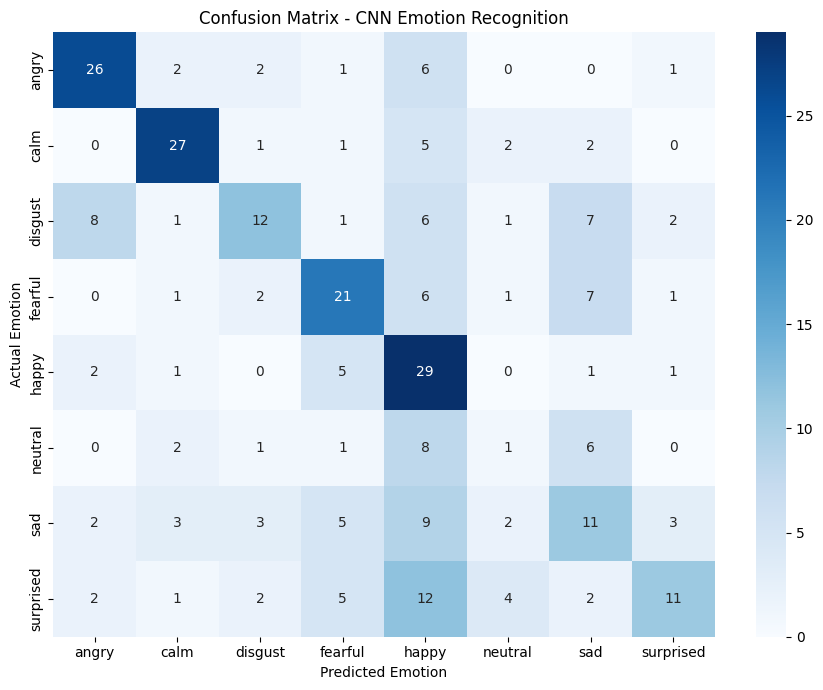

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Confusion Matrix - CNN Emotion Recognition")
plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.65      0.68      0.67        38
        calm       0.71      0.71      0.71        38
     disgust       0.52      0.32      0.39        38
     fearful       0.53      0.54      0.53        39
       happy       0.36      0.74      0.48        39
     neutral       0.09      0.05      0.07        19
         sad       0.31      0.29      0.30        38
   surprised       0.58      0.28      0.38        39

    accuracy                           0.48       288
   macro avg       0.47      0.45      0.44       288
weighted avg       0.49      0.48      0.47       288



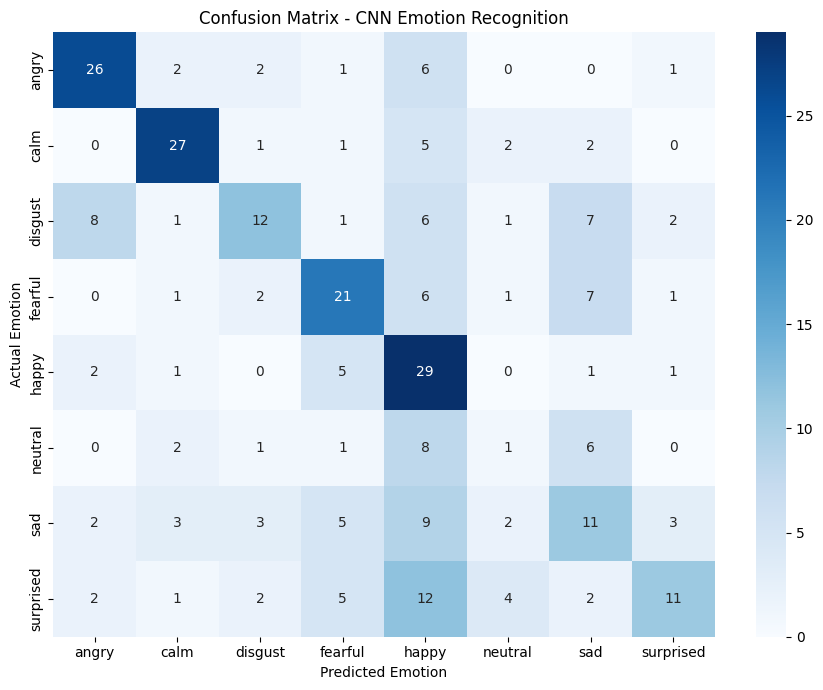

✅ Confusion matrix image saved!


In [20]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Confusion Matrix - CNN Emotion Recognition")
plt.tight_layout()

plt.savefig(
    "/content/confusion_matrix_emotion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Confusion matrix image saved!")

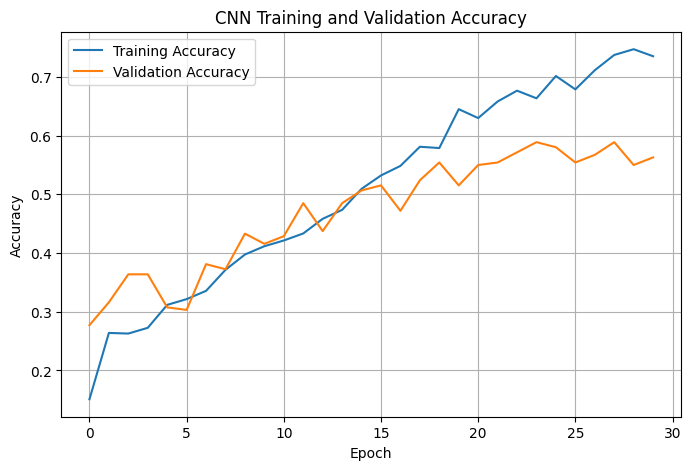

✅ Accuracy graph saved!


In [21]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.savefig(
    "/content/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Accuracy graph saved!")

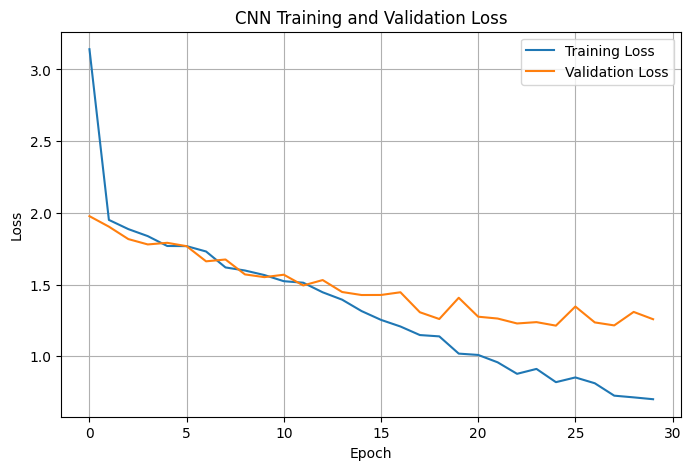

✅ Loss graph saved!


In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid()

plt.savefig(
    "/content/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Loss graph saved!")

In [23]:
cnn_model.save("/content/emotion_recognition_cnn.h5")

print("✅ CNN model saved!")

✅ CNN model saved!


In [28]:
from google.colab import files

files.download("/content/accuracy_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
files.download("/content/loss_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
cnn_model.save("/content/emotion_recognition_cnn.h5")

In [31]:
from google.colab import files

files.download("/content/emotion_recognition_cnn.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>